In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

import pickle

import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_excel("medical-insurance-dataset.xlsm")

In [6]:
df.sample(5)

,age,sex,bmi,children,smoker,region,charges
225,55,male,33.880,3,no,southeast,11987.16820
613,34,female,19.000,3,no,northeast,6753.03800
1187,62,female,32.680,0,no,northwest,13844.79720
122,20,female,28.975,0,no,northwest,2257.47525
19,30,male,35.300,0,yes,southwest,36837.46700


In [7]:
df.shape

(1338, 7)

In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [10]:
df.duplicated().sum()

np.int64(1)

In [11]:
df = df.drop_duplicates()

In [12]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [13]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [14]:
X = df.drop(columns=['charges'])
Y = df['charges']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

train_df = x_train.copy()
train_df['charges'] = y_train

print(x_train.shape)
print(x_test.shape)

(1069, 6)
(268, 6)


In [15]:
print('Skewness (Target Variable): ', y_train.skew())

pt = PowerTransformer(method='yeo-johnson')

y_train_transform = pt.fit_transform(y_train.values.reshape(-1,1)).ravel()

print('Skewness (Transformed Target Variable)', skew(y_train_transform))

Skewness (Target Variable):  1.5098846374989072
Skewness (Transformed Target Variable) -0.009681102629655727


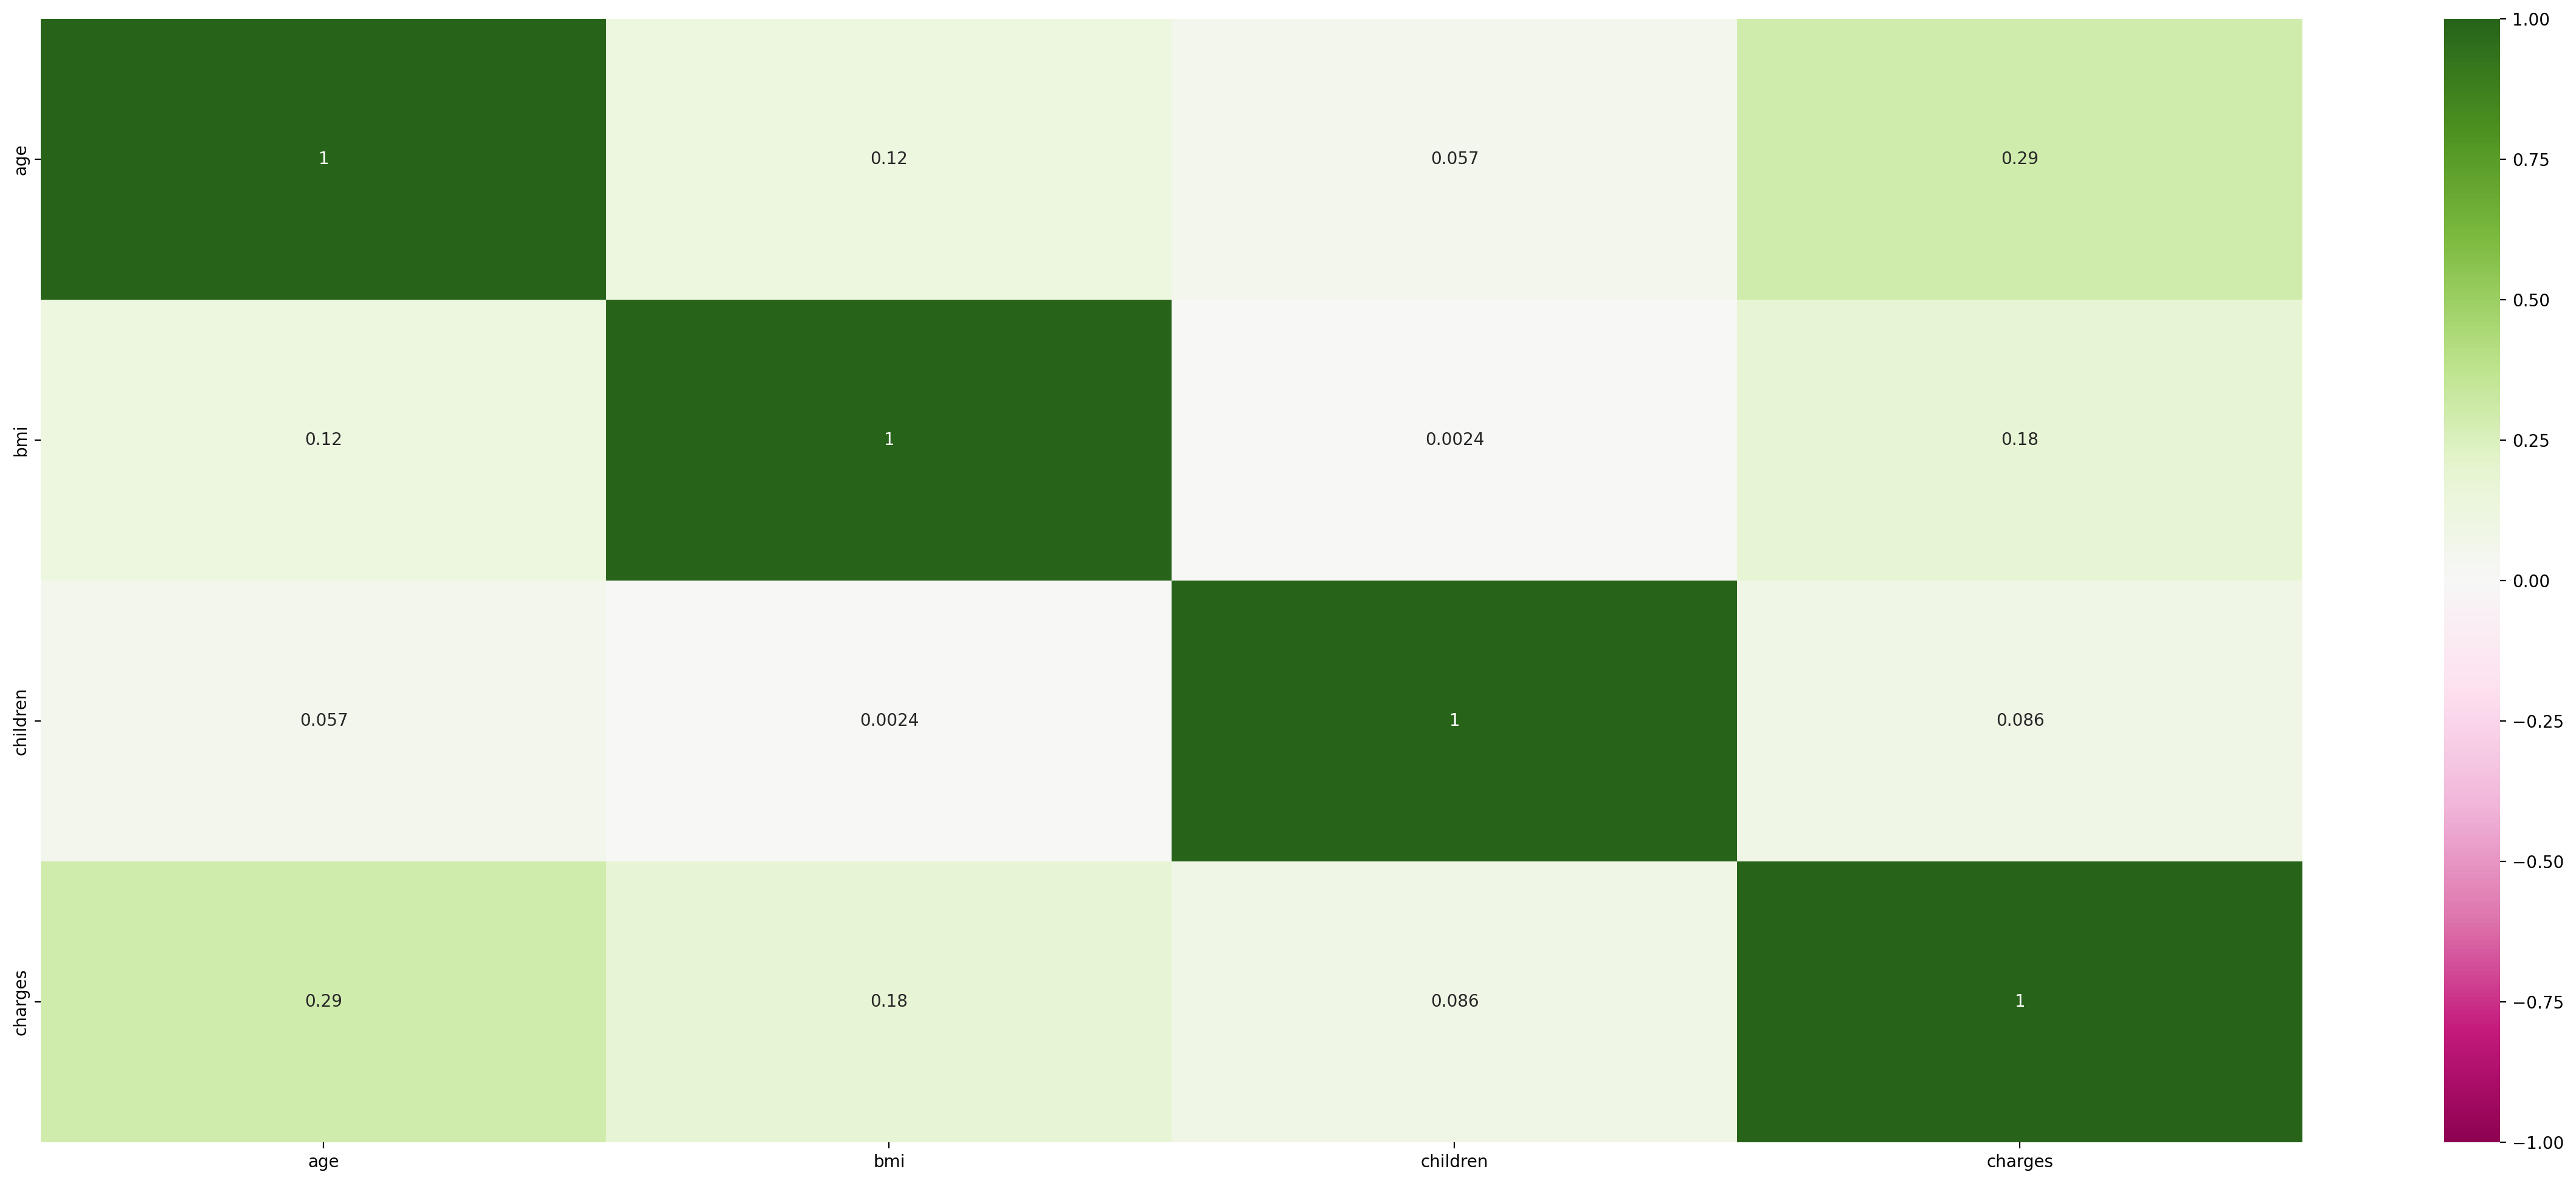

In [16]:
plt.figure(figsize = (30,12), dpi = 200)
sns.heatmap(train_df.select_dtypes('number').corr(), annot = True, vmin = -1, vmax = +1, cmap = "PiYG")
plt.show()

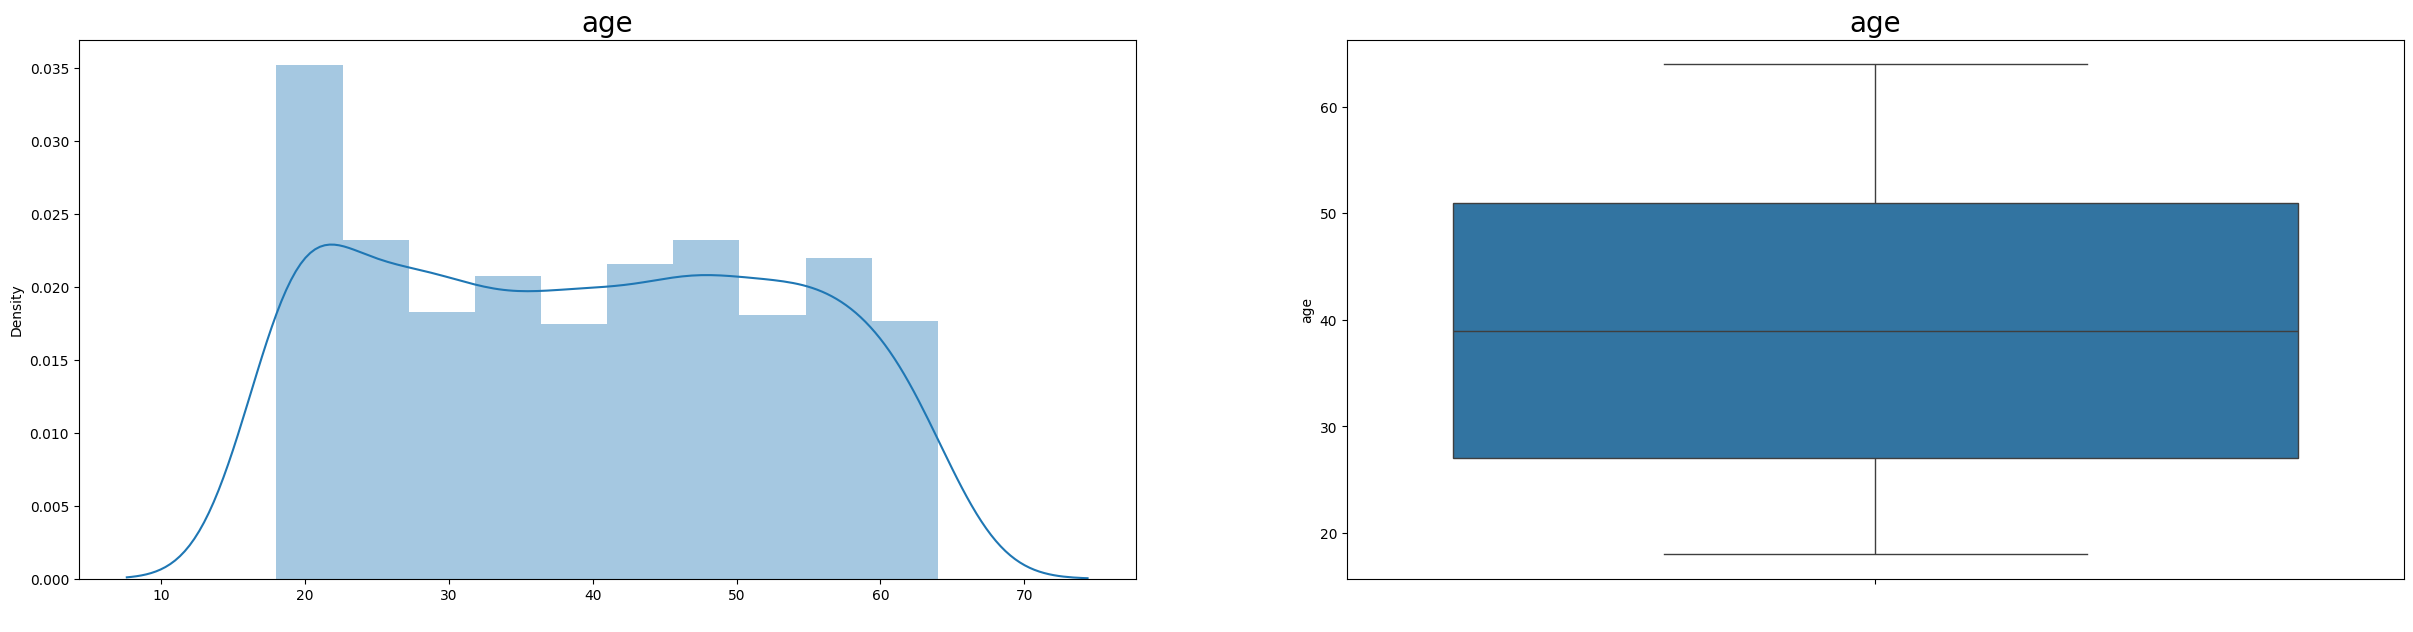

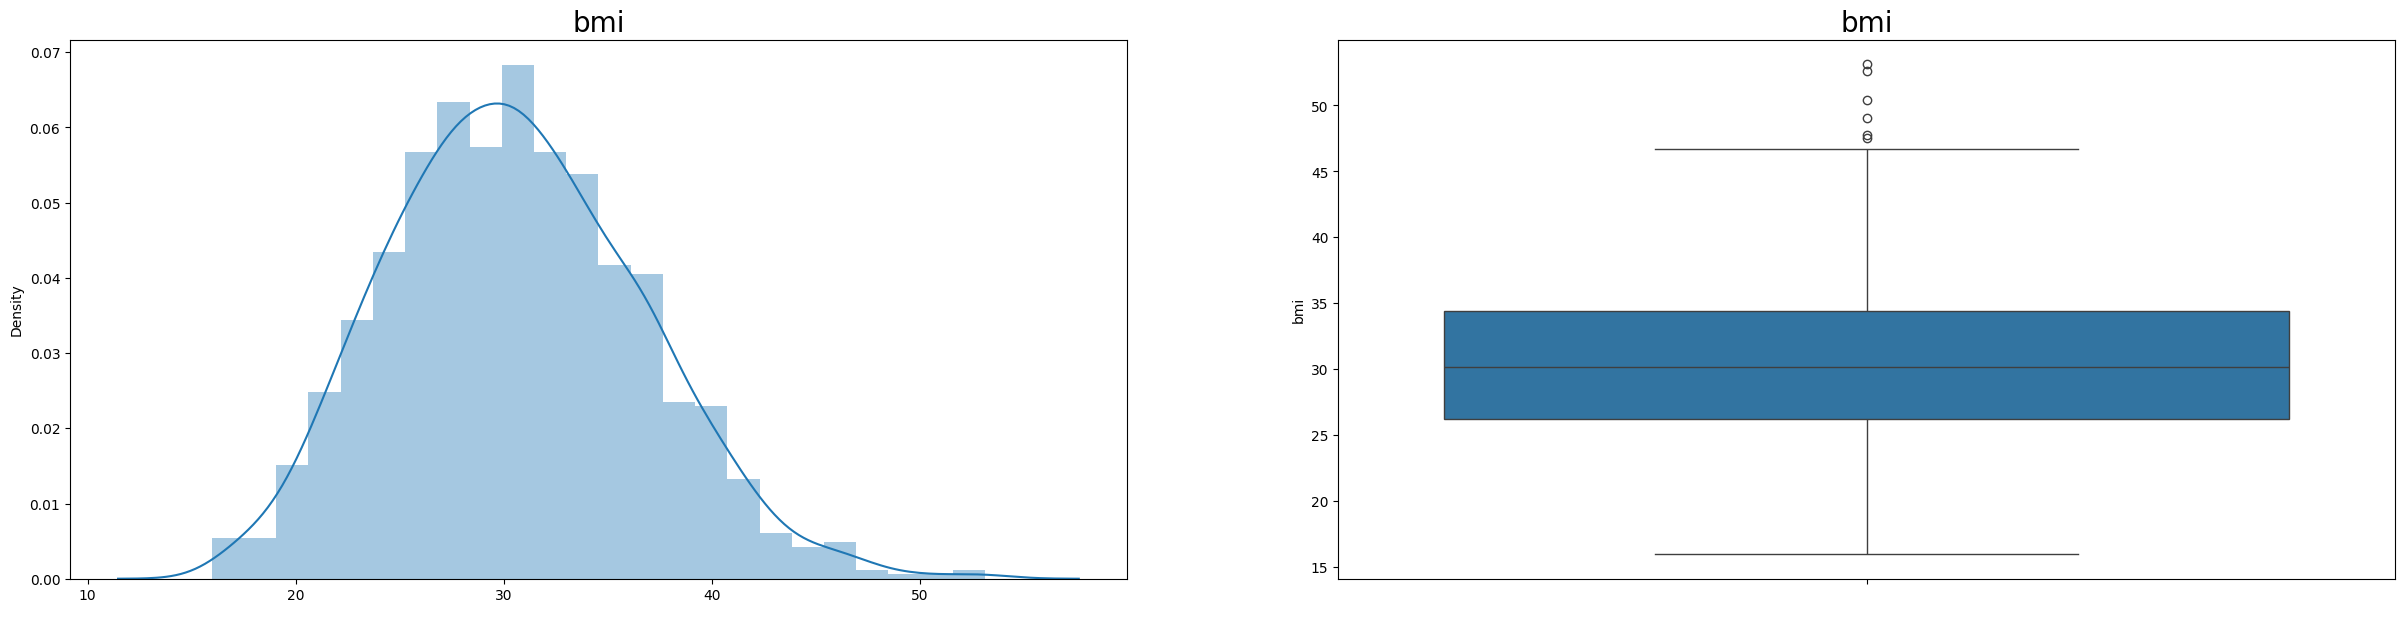

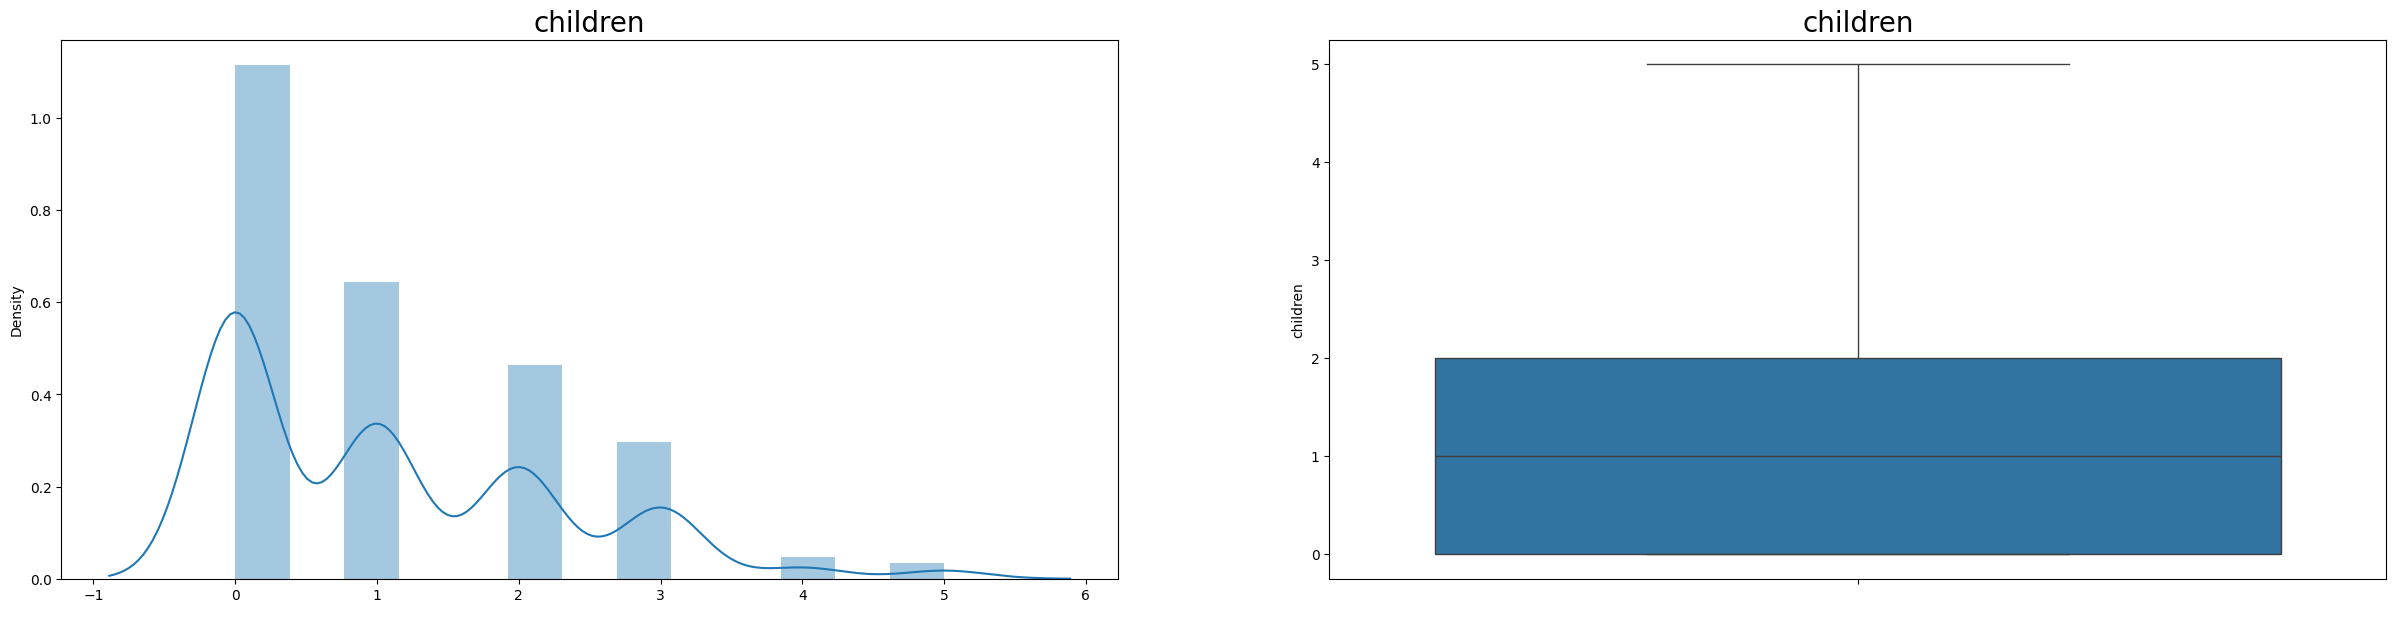

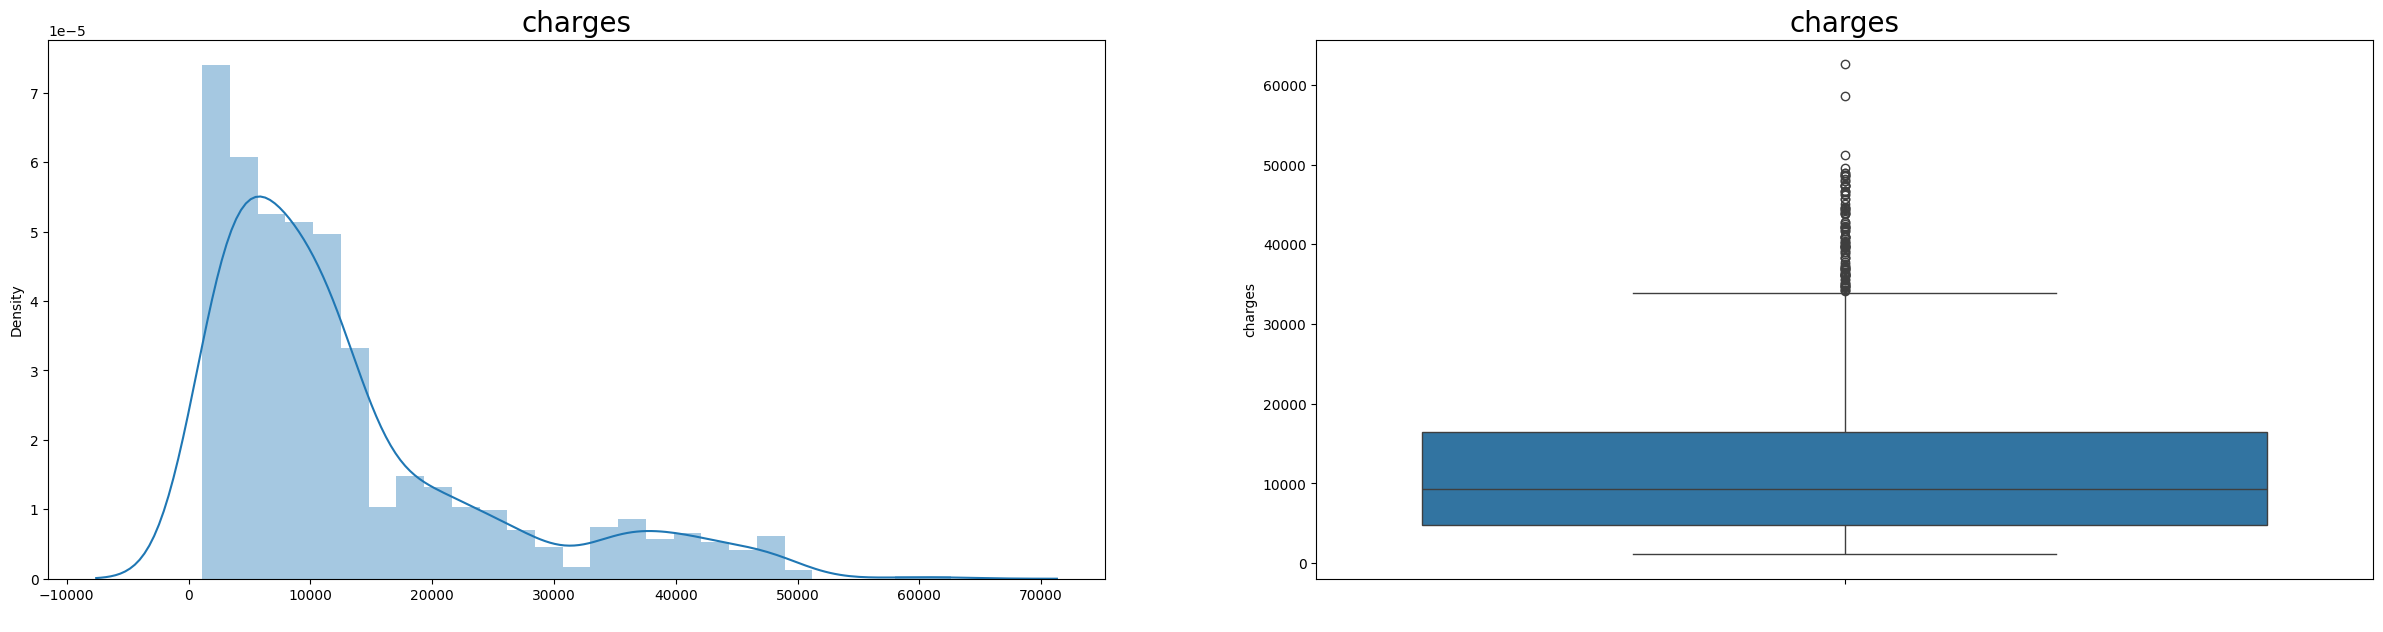

In [17]:
for col in train_df.select_dtypes('number').columns:
    plt.figure(figsize = (30,7))
    plt.subplot(1,2,1)
    sns.distplot(train_df[col])
    plt.xlabel(" ")

    plt.title(col, size = 20)
    
    plt.subplot(1,2,2)
    sns.boxplot(y = train_df[col])
    plt.title(col, size = 20)
    plt.show()

In [18]:
vif_df = pd.DataFrame()

features_to_check = train_df.select_dtypes('number')
vif_df["Feature"] = features_to_check.columns

vif_df["VIF"] = [variance_inflation_factor(features_to_check.values, i) for i in range(len(features_to_check.columns))]

print(vif_df.sort_values(by="VIF", ascending=False))

    Feature       VIF
0       age  8.264562
1       bmi  8.116392
3   charges  2.499254
2  children  1.803556


In [19]:
for col in x_train.select_dtypes('str').columns.tolist():
    print(col, ': ',df[col].unique(), '\n')

sex :  <ArrowStringArray>
['female', 'male']
Length: 2, dtype: str 

smoker :  <ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str 

region :  <ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str 



In [20]:
x_train.select_dtypes('number').skew()

age         0.066010
bmi         0.318271
children    0.952955
dtype: float64

In [21]:
std_num_cols = ['age', 'bmi']
skewed_cols = ['children']
binary_cat_cols = ['sex', 'smoker']
nominal_cat_cols = ['region']

In [22]:
linear_skewed_col_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('deskew', PowerTransformer(method='yeo-johnson')),
    ('scaling', StandardScaler())
])

linear_std_col_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaling', StandardScaler())
])

tree_skewed_col_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('deskew', PowerTransformer(method='yeo-johnson'))
])

tree_std_col_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

binary_col_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

linear_nominal_col_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

tree_nominal_col_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


In [23]:

preprocessor_linear = ColumnTransformer(transformers=[
    ('skewed_cols', linear_skewed_col_pipeline, skewed_cols),
    ('std_cols', linear_std_col_pipeline, std_num_cols),
    ('binary_cols', binary_col_pipeline, binary_cat_cols),
    ('linear_nominal_col', linear_nominal_col_pipeline, nominal_cat_cols)
],remainder='drop')

preprocessor_tree = ColumnTransformer(transformers=[
    ('skewed_cols', tree_skewed_col_pipeline, skewed_cols),
    ('std_cols', tree_std_col_pipeline, std_num_cols),
    ('binary_cols', binary_col_pipeline, binary_cat_cols),
    ('tree_nominal_col', tree_nominal_col_pipeline, nominal_cat_cols)
],remainder='drop')


In [24]:
pipeline = Pipeline(steps=[
        ('preprocessor', None),
        ('model', None)
    ])

In [25]:
def adjusted_r2(r2, X):
    n = X.shape[0]
    p = X.shape[1]
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

In [26]:
algorithms = {
    'Linear Regression': [LinearRegression(), preprocessor_linear],
    "Ridge Regression": [Ridge(random_state=42), preprocessor_linear],
    "Lasso Regression": [Lasso(random_state=42), preprocessor_linear],
    "KNeighborsRegressor": [KNeighborsRegressor(), preprocessor_linear],
    "Support Vector Machine (SVR)": [SVR(), preprocessor_linear],
    "Decision Tree": [DecisionTreeRegressor(random_state=42), preprocessor_tree],
    "Random Forest": [RandomForestRegressor(random_state=42), preprocessor_tree],
    "Gradient Boosting": [GradientBoostingRegressor(random_state=42), preprocessor_tree],
    "XGBoost": [XGBRegressor(random_state=42), preprocessor_tree]
}

prediction_metrics = pd.DataFrame(columns=['Model', 'Train RMSE', 'Test RMSE', 'Train MSE', 'Test MSE', 'Train MAE', 'Test MAE', 'Train R2', 'Test R2', 'Train Adjusted R2', 'Test Adjusted R2'])

for model_name, (model, preprocessor) in algorithms.items():
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(x_train, y_train_transform)
        
    test_predictions = pipeline.predict(x_test)
    actual_test_pred = pt.inverse_transform(test_predictions.reshape(-1,1)).ravel()    
    
    train_predictions = pipeline.predict(x_train)
    actual_train_pred = pt.inverse_transform(train_predictions.reshape(-1,1)).ravel()    

    
    test_r2 = r2_score(y_test, actual_test_pred)
    test_adjusted_r2 = adjusted_r2(test_r2, x_test)
    test_mae = mean_absolute_error(y_test, actual_test_pred)
    test_mse = mean_squared_error(y_test, actual_test_pred)
    test_rmse = root_mean_squared_error(y_test, actual_test_pred)
    
    train_r2 = r2_score(y_train, actual_train_pred)
    train_adjusted_r2 = adjusted_r2(train_r2, x_train) 
    train_mae = mean_absolute_error(y_train, actual_train_pred)
    train_mse = mean_squared_error(y_train, actual_train_pred)
    train_rmse = root_mean_squared_error(y_train, actual_train_pred)
    
    prediction_metrics.loc[len(prediction_metrics)] = [model_name, round(train_rmse, 5), round(test_rmse, 5), round(train_mse, 4), round(test_mse, 4), round(train_mae, 5), round(test_mae, 5), round(train_r2, 5), round(test_r2, 5), round(train_adjusted_r2, 5), round(test_adjusted_r2, 5)]
    
prediction_metrics = prediction_metrics.sort_values(by='Test R2', ascending= False).set_index('Model')

prediction_metrics

,Train RMSE,Test RMSE,Train MSE,Test MSE,Train MAE,Test MAE,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2
Model,,,,,,,,,,
Gradient Boosting,4112.89847,4226.14693,1.691593e+07,1.786032e+07,1822.65873,2035.14776,0.87645,0.90280,0.87575,0.90057
Random Forest,2328.53983,4397.61526,5.422098e+06,1.933902e+07,973.64758,2076.76549,0.96040,0.89476,0.96017,0.89234
Support Vector Machine (SVR),4842.03494,5337.84979,2.344530e+07,2.849264e+07,2167.88197,2412.01160,0.82876,0.84494,0.82779,0.84138
Decision Tree,0.00000,6221.60438,0.000000e+00,3.870836e+07,0.00000,2966.86554,1.00000,0.78935,1.00000,0.78451
Ridge Regression,7762.87837,6804.33519,6.026228e+07,4.629898e+07,4067.12597,3633.03316,0.55986,0.74804,0.55737,0.74225
Linear Regression,7804.60130,6821.69031,6.091180e+07,4.653546e+07,4081.42940,3626.96653,0.55511,0.74675,0.55260,0.74093
XGBoost,1069.17874,7583.53575,1.143143e+06,5.751001e+07,481.87275,3138.79993,0.99165,0.68703,0.99160,0.67984
KNeighborsRegressor,6234.28059,9360.96212,3.886625e+07,8.762761e+07,3246.55669,4899.78906,0.71613,0.52313,0.71452,0.51217
Lasso Regression,12355.03402,14521.75195,1.526469e+08,2.108813e+08,8119.08356,9304.14294,-0.11491,-0.14762,-0.12120,-0.17400


In [ ]:
param_grids = {
    'Random Forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5],
        'model__min_samples_leaf': [1, 2],
        'model__max_features': ['sqrt', 'log2']
    },
    'Gradient Boosting': {
        'model__n_estimators': [50, 80, 100, 150],
        'model__max_depth': [2, 3, 4], 
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.7, 0.8, 1.0],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    },
    'Linear Regression': {},
    'Ridge Regression': {
        'model__alpha': [0.1, 1.0, 10.0, 100.0]
    },
    'Lasso Regression': {
        'model__alpha': [0.01, 0.1, 1.0, 10.0]
    },
    'Decision Tree': {
        'model__max_depth': [None, 5, 10, 20],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    },
    'KNeighborsRegressor': {
        'model__n_neighbors': [3, 5, 7, 10],
        'model__weights': ['uniform', 'distance']
    },
    'Support Vector Machine (SVR)': {
        'model__C': [0.1, 1, 10],
        'model__epsilon': [0.1, 0.2, 0.5]
    }
}

model_name = prediction_metrics['Test R2'].idxmax()
final_model = algorithms[model_name]

grid_pipeline = Pipeline(steps=[
    ('preprocessor', final_model[1]),
    ('model', final_model[0])
    ])

param_grid = param_grids.get(model_name, {})

grid_search = GridSearchCV(
    grid_pipeline,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(x_train, y_train_transform)

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

train_pred = best_model.predict(x_train)
actual_train_pred = pt.inverse_transform(train_pred.reshape(-1,1)).ravel()

test_pred = best_model.predict(x_test)
actual_test_pred = pt.inverse_transform(test_pred.reshape(-1,1)).ravel()

final_train_r2 = r2_score(y_train, actual_train_pred)
final_test_r2 = r2_score(y_test, actual_test_pred)
final_train_adjusted_r2 = adjusted_r2(final_train_r2, x_train)
final_test_adjusted_r2 = adjusted_r2(final_test_r2, x_test)
final_train_rmse = root_mean_squared_error(y_train, actual_train_pred)
final_test_rmse = root_mean_squared_error(y_test, actual_test_pred)
final_train_mse = mean_squared_error(y_train, actual_train_pred)
final_test_mse = mean_squared_error(y_test, actual_test_pred)
final_train_mae = mean_absolute_error(y_train, actual_train_pred)
final_test_mae = mean_absolute_error(y_test, actual_test_pred)

final_metrics = pd.DataFrame({
    'Model': [model_name], 
    'Train RMSE': [final_train_rmse], 
    'Test RMSE': [final_test_rmse],
    'Train MSE': [final_train_mse],
    'Test MSE': [final_test_mse],
    'Train MAE': [final_train_mae],
    'Test MAE': [final_test_mae], 
    'Train R2': [final_train_r2], 
    'Test R2': [final_test_r2],
    'Adjusted Train R2': [final_train_adjusted_r2], 
    'Adjusted Test R2': [final_test_adjusted_r2]
})


Fitting 5 folds for each of 972 candidates, totalling 4860 fits
The Best Hyperparameters Found (Gradient Boosting):


ValueError: too many values to unpack (expected 2)

In [28]:
print(f"The Best Hyperparameters Found ({model_name}):")
for param, value in best_params.items():
    print(f'{param}: {value}')

print('\n')

final_metrics

The Best Hyperparameters Found (Gradient Boosting):
model__learning_rate: 0.1
model__max_depth: 3
model__min_samples_leaf: 2
model__min_samples_split: 5
model__n_estimators: 50
model__subsample: 1.0




,Model,Train RMSE,Test RMSE,Train MSE,Test MSE,Train MAE,Test MAE,Train R2,Test R2,Adjusted Train R2,Adjusted Test R2
0,Gradient Boosting,4327.625073,4321.681154,1.872834e+07,1.867693e+07,1923.970556,2032.944082,0.863212,0.89836,0.862439,0.896024


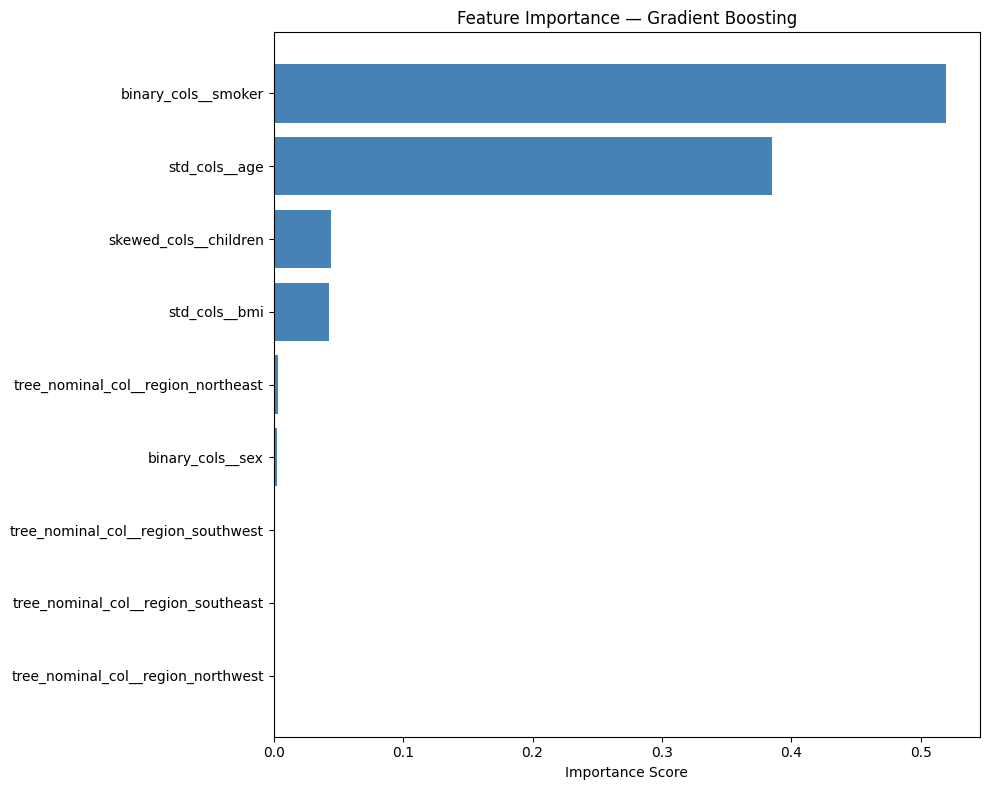

In [29]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
importances = best_model.named_steps['model'].feature_importances_

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True) 

plt.figure(figsize=(10, 8))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title(f'Feature Importance — {model_name}')
plt.tight_layout()
plt.show()

In [ ]:
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
    
with open('target_transformer.pkl', 'wb') as f:
    pickle.dump(pt, f)